# 我使用了什么库？

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# 需要导入的库
import numpy as np
from sklearn.linear_model import LinearRegression

import torch
import torch.optim as optim
import torch.nn as nn
from torchviz import make_dot



# 然后，我要干什么？

目的是想了解pytorch在梯度计算方面是如何工作的
- 在此基础上仍然使用单特征线性回归模型
- 然后简单回顾numpy实现下线性回归的步骤

> 注意,我们现在没有去操心回归问题的结果,当前注意力放在**梯度下降**这一过程上

# 简单的回归问题

**Q**: 单特征线性回归模型的公式和每个参数的意义

**Q**: 如果把单特征线性回归视为神经网络，其计算图是什么样的？

# Numpy实现下线性回归的步骤

> 具体代码参考ch00

在处理梯度下降之前
1. 数据生成
2. 数据拆分

处理梯度下降
1. 随机初始化
2. 前向传播(预测)
3. 计算损失: 误差,损失,MSE,梯度下降的种类,损失面
4. 计算梯度: 横截面,偏导数,梯度,反向传递
5. 更新参数: 超参数,学习率，学习率的大小,标准化的必要性
6. 循环往复: 周期,梯度下降的各种更新次数,梯度下降的各种逼近方式


# 然后，我要干什么？

接下来要汇总ch00的代码,来实现numpy版本的线性回归模型，以此：
- 展示任务的大框架，因为步骤是基本不变的
- 展示主要的痛点和短板，来对比pytorch的便捷性

然后就会介绍pytorch的相关概念

# Numpy的线性回归实现

In [3]:
# 程序2-1: 生成数据
# seed: 42

N=100
true_b=1
true_w=2

np.random.seed(42)
x = np.random.rand(N,1)
ep = .1*np.random.randn(N,1)
y=true_b+true_w*x +ep

# 程序2-1: 切分数据

# 打乱数据集索引
idx = np.arange(N)
np.random.shuffle(idx)

# 使用前 80% 作为训练集
train_idx = idx[:int(N*.8)]
# 使用剩余索引作为验证集
val_idx = idx[int(N*.8):]

# 生成训练集和验证集
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

In [4]:
# 程序2-2: Numpy的线性回归实现

# 使用批量梯度下降
# 使用固定种子
np.random.seed(42)

# 随机初始化
b = np.random.randn(1)
w = np.random.randn(1)

print(b,w)


# 设置超参数
lr = 0.1
n_epochs = 1000

# 周期循环
for epoch in range(n_epochs):
    # 前向传递
    yhat = b + w * x_train
    # 计算误差和损失
    error = (yhat - y_train)
    # MSE
    loss = (error ** 2).mean()
    # 计算梯度
    b_grad = 2 * error.mean()
    w_grad = 2 * (x_train * error).mean()
    # 更新参数
    b = b - lr * b_grad
    w = w - lr * w_grad

print(b,w)




# 对比检测
linr = LinearRegression()
linr.fit(x_train, y_train)
print("Answer:",linr.intercept_,linr.coef_[0])







[0.49671415] [-0.1382643]
[1.02354094] [1.96896411]
Answer: [1.02354075] [1.96896447]


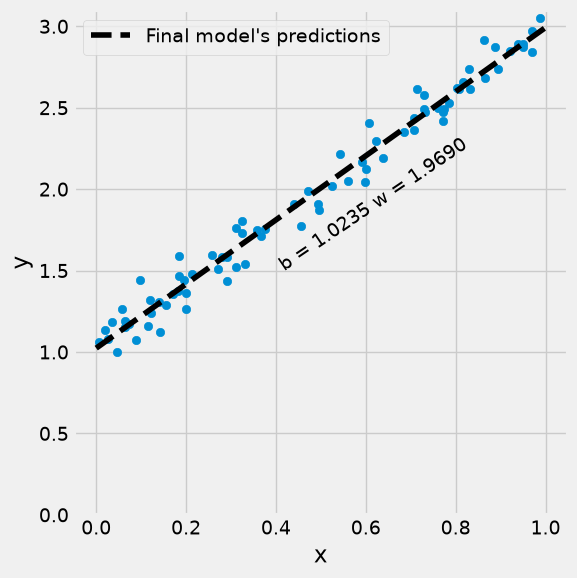

In [5]:
# 可视化对比结果
from plots.chapter1 import *
fig = figure3(x_train, y_train)

# Pytorch


## 张量

**Q:** 标量,向量,矩阵,张量的区别和实际划分是什么

**Q:** 张量在numpy中以什么方式出现

结合代码回答:

**Q:** pytorch如何创建一个张量和获取其形状

**Q:** pytorch reshape一个张量的方法,有什么特殊行为

**Q:** pytorch 如何复制一个张量,有什么注意事项和特殊行为


In [6]:
# 程序2-3: 创建pytoch 张量

var_scalar = torch.tensor(3.14159)
var_vector = torch.tensor([1,2,3])
var_matrix = torch.ones((2,3),dtype=torch.float)
var_matrix2 = torch.zeros((2,2),dtype=torch.int)
var_tensor = torch.randn([2,3,4],dtype=torch.float)

print(var_scalar,'\n',var_vector,'\n',var_matrix,'\n',var_matrix2,'\n',var_tensor)

# 访问张量
print(var_tensor[0,0,1],var_tensor[1][0][1])
print(var_tensor[0,0,(0,1,2)])
print(var_tensor[0,0,slice(0,3,2)])


tensor(3.1416) 
 tensor([1, 2, 3]) 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 
 tensor([[0, 0],
        [0, 0]], dtype=torch.int32) 
 tensor([[[ 0.1214,  1.3218, -1.3869,  0.8126],
         [ 0.7320,  0.1605, -0.6978,  0.6630],
         [-1.1104, -1.3313,  0.2947,  0.0845]],

        [[-0.6387,  0.8426, -1.2780,  0.3570],
         [-0.4736, -0.3934, -0.4342,  0.3914],
         [-2.2110, -0.3838, -0.1525,  0.3274]]])
tensor(1.3218) tensor(0.8426)
tensor([ 0.1214,  1.3218, -1.3869])
tensor([ 0.1214, -1.3869])


In [7]:
# 程序2-4: 获取张量形状

print(var_tensor.size(),var_tensor.shape)

# 标量是空形状,因为其零维度
print(var_scalar.size(),var_scalar.shape)

torch.Size([2, 3, 4]) torch.Size([2, 3, 4])
torch.Size([]) torch.Size([])


In [8]:
# 程序2-5: 重塑reshape张量

same_matrix = var_matrix2.view(1,4)
print(same_matrix,same_matrix.shape)

same_matrix[0,1] =1
print(var_matrix2,same_matrix)

# 注意reshape只是可能创建副本
same_matrix2 = var_matrix2.reshape(1,4)
same_matrix2[0,1] =2
print(var_matrix2,same_matrix2)

tensor([[0, 0, 0, 0]], dtype=torch.int32) torch.Size([1, 4])
tensor([[0, 1],
        [0, 0]], dtype=torch.int32) tensor([[0, 1, 0, 0]], dtype=torch.int32)
tensor([[0, 2],
        [0, 0]], dtype=torch.int32) tensor([[0, 2, 0, 0]], dtype=torch.int32)


In [9]:
# 程序2-6: 复制张量数据

# new_tensor方法: 注意warning内容,会继承dtype和grad相关信息
diff_matrix = var_matrix2.new_tensor(var_matrix2.view(1,4))
print(diff_matrix,diff_matrix.shape)

diff_matrix[0,1]=3
print(var_matrix2,diff_matrix)



tensor([[0, 2, 0, 0]], dtype=torch.int32) torch.Size([1, 4])
tensor([[0, 2],
        [0, 0]], dtype=torch.int32) tensor([[0, 3, 0, 0]], dtype=torch.int32)


C:\Users\a7183\AppData\Local\Temp\ipykernel_25048\1392254750.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  diff_matrix = var_matrix2.new_tensor(var_matrix2.view(1,4))


In [10]:
# 程序2-6: 复制张量数据

# clone + detach方法: 从计算图中删除张量
another_matrix = var_matrix2.view(1,4).clone().detach()
another_matrix[0,1]=4
print(var_matrix2,another_matrix,another_matrix.requires_grad)

tensor([[0, 2],
        [0, 0]], dtype=torch.int32) tensor([[0, 4, 0, 0]], dtype=torch.int32) False


## 然后，我要干什么？

固然创建了张量,但是pytorch是可以利用显卡(cuda)来及性能向量计算的

所以，以加载训练数据为例子，展示
- 如何将numpy传入pytorch
- 如何创建CPU和GPU张量

## 加载数据,设备和CUDA

**Q**: CPU张量和GPU张量是什么？有什么区别？

结合代码回答:

**Q**: 如何将numpy传入pytorch和转回,有什么特殊行为

**Q**: 如何检测是否存在设备并打印设备信息？

**Q**: 如何创建GPU张量？

**Q**: 如何识别张量类型？

**Q**: 如何将GPU张量变为numpy数组？

In [11]:
# 程序2-7: numpy数组装入pytorch数组

print(x_train.shape,y_train.shape)

# 效果等同from_numpy()
x_train_tensor = torch.as_tensor(x_train)

print(x_train.dtype,x_train_tensor.dtype)

float_tensor = x_train_tensor.float()
print(float_tensor.dtype)

# 转回numpy
print(float_tensor.numpy().dtype)

(80, 1) (80, 1)
float64 torch.float64
torch.float32
float32


In [12]:
# 程序2-7-1: as_tensor和from_numpy 教程

# 浅拷贝

dummpy_array = np.array([1,2,3])
dummpy_tensor = torch.as_tensor(dummpy_array)

dummpy_array[1]=0

print(dummpy_tensor)


# 复制数据

dummpy_array2 = torch.tensor(dummpy_array)
dummpy_array[1]=1
print(dummpy_array2,dummpy_tensor)


tensor([1, 0, 3])
tensor([1, 0, 3]) tensor([1, 1, 3])


In [13]:
# 程序2-8: GPU环境配置和GPU张量创建

device = 'cuda' if torch.cuda.is_available() else 'cpu'

n_cudas = torch.cuda.device_count()
for i in range(n_cudas):
    print(torch.cuda.get_device_name(i),torch.cuda.get_device_capability(i))
,
# 张量创建
gpu_tensor = torch.as_tensor(x_train).to(device)
print(gpu_tensor[0])

tensor([0.7713], dtype=torch.float64)


In [14]:
# 程序2-9: 加载Numpy到GPU张量

x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

# type代表张量存在的位置
print(type(x_train),type(x_train_tensor),x_train_tensor.type())


<class 'numpy.ndarray'> <class 'torch.Tensor'> torch.FloatTensor


In [15]:
# 程序2-10: 从GPU张量到numpy

back_to_numpy = x_train_tensor.cpu().numpy()

print(back_to_numpy.shape)

(80, 1)


## 然后，我要干什么？

目前，pytorch张量的范围仅仅涉及了训练数据, 接着要把**需要计算梯度的参数**也加纳入pytorch的控制
接着，要利用这些梯度进行**AutoGrad自动微分**

## 创建参数

**Q**: 训练数据的张量和用于训练的参数张量有什么区别？

结合代码回答:

**Q**: 如何设置pytorch的随机种子？

**Q**: pytorch方法以下划线结束的方法是什么意思？

**Q**: 如何设置一个张量需要计算梯度？(3种方式)

In [16]:
# 程序2-11: 方法一: CPU张量设置方法

torch.manual_seed(42)

b = torch.randn(1,requires_grad=True,dtype=torch.float)
w = torch.randn(1,requires_grad=True,dtype=torch.float)

print(b,w)

tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


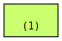

In [17]:
# 程序2-12: 貌似"丢失"梯度（GPU张量设置梯度的尝试）


torch.manual_seed(42)

b = torch.randn(1,requires_grad=True,dtype=torch.float).to(device)
w = torch.randn(1,requires_grad=True,dtype=torch.float).to(device)

print(b,w)



# ps:但是为什么b.requires_grad 是True?
# 结合计算图可以发现,产生了多余的步骤
make_dot(b)


tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


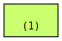

In [18]:
# 程序2-13: 方法二: GPU张量设置方法（手动设置）


torch.manual_seed(42)

b = torch.randn(1,dtype=torch.float).to(device)
w = torch.randn(1,dtype=torch.float).to(device)

b.requires_grad_()
w.requires_grad_()

print(b,w)

# 对比程序2-12产生的计算图
make_dot(b)


tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


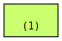

In [19]:
# 程序2-14: 方法三: GPU张量设置方法（创建时设置）

torch.manual_seed(42)

b = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)
w = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)

print(b,w)

# 对比程序2-12产生的计算图
make_dot(b)

## Autograd

**Q**: 复习下，梯度是怎么计算的？

**Q**: 梯度下降过程中有哪些张量是需要梯度计算的？

**Q**: 反向传播的作用是什么？

**Q**: 动态计算图记录了什么？

结合代码:

**Q**: 怎么执行反向传播?如何查看梯度？

**Q**: pytorch的梯度为什么要累计？如何在下列实践中故意触发？

**Q**: 如何将梯度归零（防止梯度累计）？

**Q**: 在更新参数的部分，解释下为什么第一步为什么会丢失grad属性和第二步的意图，以及为什么失败,如果想成功实现第三步要做点什么？怎么做？



In [20]:
# 程序2-15: 使用pytorch的反向传递（梯度计算）

# 前向传递
yhat = b + w * x_train_tensor

# 误差和损失
error = (yhat - y_train_tensor)
loss = (error ** 2).mean()

# 计算参数b和w的梯度

loss.backward()

print(error.requires_grad,yhat.requires_grad,b.requires_grad,w.requires_grad,loss.requires_grad)

print(y_train_tensor.requires_grad,x_train_tensor.requires_grad)


True True True True True
False False


In [21]:
# 程序2-16: 查看梯度值

print(b.grad,w.grad)

# 访问非叶子节点的梯度会触发warning
#print(error.grad,yhat.grad,loss.grad)


tensor([-3.1125]) tensor([-1.8156])


In [22]:
# 程序2-17: 梯度归零

b.grad.zero_(),w.grad.zero_()

print(b.grad,w.grad)


tensor([0.]) tensor([0.])


In [23]:
# 程序2-18: 更新参数
lr = 0.1

torch.manual_seed(42)
b = torch.randn(1, requires_grad=True,dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True,dtype=torch.float, device=device)

n_epochs = 1000

for epoch in range(n_epochs):
    # 前向传递
    yhat = b + w * x_train_tensor

    # 误差和损失
    error = (yhat - y_train_tensor)
    loss = (error ** 2).mean()

    # 反向传播计算梯度
    loss.backward()

    # 方法一: 手动更新参数（报错）
    # b = b - lr * b.grad
    # w = w - lr * w.grad
    # print(b)

    # 方法二: 使用原地手动更新
    # b -= lr * b.grad
    # w -= lr * w.grad

    # 方法三: 使用no_grad防止更新被纳入梯度计算
    with torch.no_grad():
        b -= lr * b.grad
        w -= lr * w.grad

    # 防止梯度累计
    b.grad.zero_()
    w.grad.zero_()

print(b, w)

tensor([1.0235], requires_grad=True) tensor([1.9690], requires_grad=True)


# 然后，我要干什么？

目前，pytorch张量的范围涉及了训练数据, 要计算梯度的参数也加纳入pytorch的控制

- 现在要研究下pytorch是如何控制这些梯度计算的？

- 然后，将更新参数的活也交给pytorch控制，省去no_grad的麻烦


# 动态计算图

**Q**: 计算图包含什么？不包含什么？

结合代码:

**Q**: 如何可视化计算图？

**Q**: 蓝色框是什么意思？

**Q**: 灰色框是什么意思？

**Q**: 绿色框是什么意思？

**Q**: 如何摘掉一个参数？

torch.Size([1]) torch.Size([1]) torch.Size([80, 1])


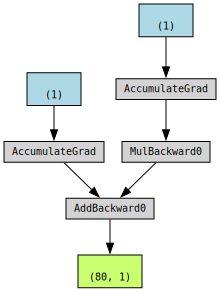

In [24]:
# 程序2-19 可视化损失（计算图）
torch.manual_seed(42)
# 随机初始化
b = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)
w = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)
# 正向传播
yhat = b + w * x_train_tensor
# 计算误差和损失
loss = ((yhat - y_train_tensor) ** 2).mean()

print(b.shape,w.shape,yhat.shape)

# 还可以用loss查看计算图, 区别只在于计算过程变长了
make_dot(yhat)


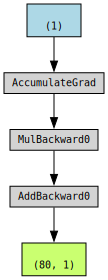

In [25]:
# 程序2-20 两种方法从计算图中摘去变量
#
#b_nograd = torch.randn(1,requires_grad=False,dtype=torch.float,device=device)
b_nograd = b.clone().detach()
yhat = b_nograd + w*x_train_tensor

make_dot(yhat)

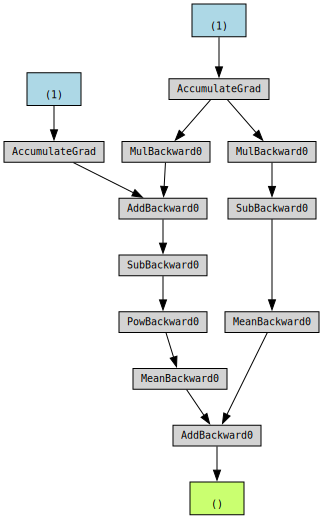

In [26]:
# 程序2-21: 梯度的流程控制

b = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)
w = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)

yhat = b + w * x_train_tensor
error = yhat - y_train_tensor
loss = (error ** 2).mean()

if loss > 0:
    yhat2 = w * x_train_tensor
    error2 = yhat2 - y_train_tensor

loss += error2.mean()

make_dot(loss)

# 优化器

**Q**: 更新参数的方法有哪些？（可查询资料）

结合代码:

**Q**: 如何定义一个优化器？

**Q**: 如何使用一个优化器？

**Q**: 如何查看优化器的状态？

In [27]:
# 程序2-22: 优化器的定义和使用(以SGD为例)

# 设置学习率
lr = 0.1

# Step0: 初始化b和w

w = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)
b = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)

# 定义SGD优化器

optim_sgd = optim.SGD([w,b],lr=lr)

# 定义周期数

n_epochs = 1000

for epoch in range(n_epochs):
    # Step1: 前向传递
    yhat = b + w * x_train_tensor

    # Step2: 计算损失
    error = (yhat - y_train_tensor)
    loss = (error ** 2).mean()

    # Step3: 计算梯度
    loss.backward()

    # Step4: 使用梯度和学习率更新参数

    optim_sgd.step()

    # 防止梯度累计
    optim_sgd.zero_grad()

print(b,w)

print(optim_sgd.state_dict())


tensor([1.0235], requires_grad=True) tensor([1.9690], requires_grad=True)
{'state': {}, 'param_groups': [{'lr': 0.1, 'momentum': 0, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1]}]}


# 然后，我要干什么？

目前，pytorch张量的范围涉及了训练数据, 要计算梯度的参数也加纳入pytorch的控制

更新参数的活也交给pytorch控制，省去no_grad的麻烦

接下来：
- 损失函数也交给pytorch封装处理
- 前向传递也要交给pytorch封装处理
- 然后再用模型类封装以上这一切！（参数，前向预测）


# 损失函数

**Q**: SSE和MSE是什么意思？

结合代码:

**Q**: 高阶函数是什么？

**Q**: 如何定义MSE的损失函数?如何使用？

**Q**: 如何定义SSE损失函数？

**Q**: 如何将gpu的数据取回本地numpy？

In [28]:
# 程序2-23: 损失的定义和使用(以MSE为例)

# 设置学习率
lr = 0.1

# Step0: 初始化b和w

w = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)
b = torch.randn(1,requires_grad=True,dtype=torch.float,device=device)

# 定义SGD优化器

optim_sgd = optim.SGD([w,b],lr=lr)

# 定义损失函数

loss_fn = nn.MSELoss(reduction='mean')

# 定义周期数

n_epochs = 1000

for epoch in range(n_epochs):
    # Step1: 前向传递
    yhat = b + w * x_train_tensor

    # Step2: 计算损失
    #error = (yhat - y_train_tensor)
    #loss = (error ** 2).mean()
    loss = loss_fn(yhat,y_train_tensor)

    # Step3: 计算梯度
    loss.backward()

    # Step4: 使用梯度和学习率更新参数

    optim_sgd.step()

    # 防止梯度累计
    optim_sgd.zero_grad()

print(b,w)



tensor([1.0235], requires_grad=True) tensor([1.9690], requires_grad=True)


In [29]:
# 程序2-24: 将loss取回本地三种方法

# loss存于gpu端
print(loss,w)

# 简单方式1
print(loss.item(),loss.tolist())
# 简单方式2
print(loss.detach().cpu().numpy())



tensor(0.0080, grad_fn=<MseLossBackward0>) tensor([1.9690], requires_grad=True)
0.008044655434787273 0.008044655434787273
0.008044655


# 前向函数

## 模型类

**Q**: 模型类要继承pytorch的什么父类？

**Q**: 什么内容计划放入模型类中？

**Q**: 要继承模型类需要覆盖或实现哪些方法？

**Q**: 在进行预测时，要特别设置什么？设置影响了什么？（训练和纯预测的时候有什么区别）

**Q**: 如何使用模型类进行前向传播(预测)？为什么要这么做？不这么做会导致什么？


结合代码:

**Q**: 如何查看模型的状态？

**Q**: 如何上传模型到设备上？

## 参数

结合代码:

**Q**: 如何封装模型需要的参数？

**Q**: 如何查看参数列表？

In [30]:
# 程序2-25 模型类和参数设置

class ManualLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # 使用Parameter对模型参数进行封装
        self.b = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.w = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    def forward(self,x):
        # 前向传播
        return self.b + self.w *x

In [31]:
# 程序2-26 Parameter对模型参数进行封装
torch.manual_seed(42)

dummy = ManualLinearRegression()
print(list(dummy.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [32]:
# 程序2-27 查看模型参数的状态

# 注意Parameter封装自动帮助处理了参数的上传问题（对比程序2-12至2-14）
for i in dummy.parameters():
    print(i)
print(dummy.state_dict())

Parameter containing:
tensor([0.3367], requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)
OrderedDict([('b', tensor([0.3367])), ('w', tensor([0.1288]))])


In [33]:
# 程序2-28 上传模型到设备

torch.manual_seed(42)

dummy = ManualLinearRegression().to(device)

In [34]:
# 程序2-29 模型类的使用

# 设置学习率
lr =0.1

# 初始化参数
torch.manual_seed(42)
model = ManualLinearRegression().to(device)

# 定义优化器
optim_sgd = optim.SGD(model.parameters(),lr=lr)
# 定义损失函数
loss_fn = nn.MSELoss(reduction='mean')

# 定义周期数
n_epochs = 1000

for epoch in range(n_epochs):
    # 注意:一定要设置,影响一些类似dropout的操作是否执行
    model.train()

    # Step1: 前向传播，注意模型的调用形式,不是直接函数调用（函数会跳过钩子）
    yhat = model(x_train_tensor)

    # Step2: 计算损失
    loss = loss_fn(yhat,y_train_tensor)

    # Step3: 反向传播计算梯度
    loss.backward()

    # Step4: 更新参数
    optim_sgd.step()
    # 注意: 别忘重置梯度
    optim_sgd.zero_grad()

print(model.state_dict())


OrderedDict([('b', tensor([1.0235])), ('w', tensor([1.9690]))])


# 然后，我要干什么？

整理下目前的情况:

- 训练数据: numpy生成,拆分数据,通过pytorch张量包装

- 模型参数: 手动继承`nn.Module`实现

- 前向传播: 手动实现单变量线性回归模型

- 损失函数: `nn.MSELoss` 包装

- 反向传播: `loss.backward`方法由动态计算图实现,替代了手动计算

- 更新参数: `optim.SGD` 包装


可以看到目前还有以下含有相对手动的逻辑:
- 线性回归模型还是自己写的逻辑
- 训练数据虽然被张量包装，但是只能支持批量梯度下降（每次使用全量数据）这一种情况，如果我想采样一部分数据，目前的逻辑是无法支持的

训练数据暂时放在一边，接下来:
- 运用现成的线性回归模型替代手写
- 让模型类能扩展处理**多层网络**


# 序列模型和层

神经网络不止一层，每层都可以看作是一个简单的模型类，每层通过前向和反向传播串联在一起，包括:
- 输入层
- 隐藏层
- 输出层

> 特点是他们的输入输出要想串联在一起，则必须符合矩阵乘法对维度的限制

Pytorch支持很多不同的层:
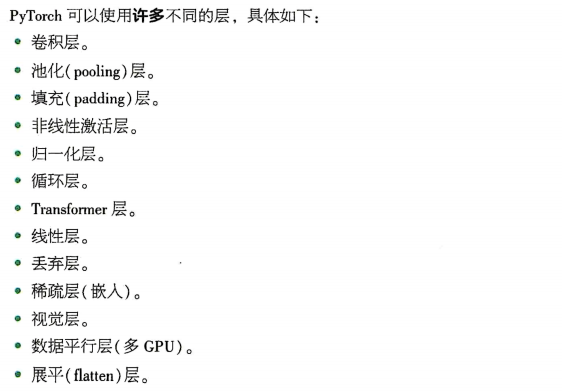

## 嵌套模型

结合代码:

**Q**: 嵌套模型如何实现？

**Q**: `nn.Linear`用到了哪些参数？作用是？

In [35]:
# 程序2-30: 现成线性模型

linear = nn.Linear(1,1)

# 输入特征,输出特征的个数
print(linear)

# 展示参数
print(linear.state_dict())


Linear(in_features=1, out_features=1, bias=True)
OrderedDict([('weight', tensor([[-0.2191]])), ('bias', tensor([0.2018]))])


In [36]:
# 程序2-31: 嵌套模型的定义和使用

class MyLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1,1)
    def forward(self,x):
        self.linear(x)

torch.manual_seed(42)

# pytorch会递归展示所有参数

dummy = MyLinearRegression().to(device)
print(list(dummy.parameters()))

print(dummy.state_dict())

[Parameter containing:
tensor([[0.7645]], requires_grad=True), Parameter containing:
tensor([0.8300], requires_grad=True)]
OrderedDict([('linear.weight', tensor([[0.7645]])), ('linear.bias', tensor([0.8300]))])


## 序列模型

结合代码

**Q**: 嵌套模型如何使用?

**Q**: 嵌套模型如何实现层的效果?如何命名层？



In [37]:
# 程序2-32: 嵌套模型的使用

torch.manual_seed(42)

model = nn.Sequential(nn.Linear(3,5),nn.Linear(5,1)).to(device)

print(model.state_dict())


OrderedDict([('0.weight', tensor([[ 0.4414,  0.4792, -0.1353],
        [ 0.5304, -0.1265,  0.1165],
        [-0.2811,  0.3391,  0.5090],
        [-0.4236,  0.5018,  0.1081],
        [ 0.4266,  0.0782,  0.2784]])), ('0.bias', tensor([-0.0815,  0.4451,  0.0853, -0.2695,  0.1472])), ('1.weight', tensor([[-0.2060, -0.0524, -0.1816,  0.2967, -0.3530]])), ('1.bias', tensor([-0.2062]))])


In [38]:
# 程序2-32: 层的命名
torch.manual_seed(42)

model = nn.Sequential()
model.add_module("Linear1",nn.Linear(3,5))
model.add_module("Linear2",nn.Linear(5,1))

model.to(device)

print(model.state_dict())


OrderedDict([('Linear1.weight', tensor([[ 0.4414,  0.4792, -0.1353],
        [ 0.5304, -0.1265,  0.1165],
        [-0.2811,  0.3391,  0.5090],
        [-0.4236,  0.5018,  0.1081],
        [ 0.4266,  0.0782,  0.2784]])), ('Linear1.bias', tensor([-0.0815,  0.4451,  0.0853, -0.2695,  0.1472])), ('Linear2.weight', tensor([[-0.2060, -0.0524, -0.1816,  0.2967, -0.3530]])), ('Linear2.bias', tensor([-0.2062]))])


# 总结目前的状况

现在，会把上述的过程拆解成python文件的形式，便于重用和突出重点:

数据生成

- numpy生成,手动拆分

数据准备:

- 训练数据: numpy生成,拆分数据,通过pytorch张量包装

模型配置:

- 超参数: 学习率手动设置

- 模型参数,前向传播: 序列模型包装的线性模型

- 损失函数: `nn.MSELoss` 包装

- 更新参数: `optim.SGD` 包装

模型训练:

- 训练循环
- 反向传播: `loss.backward`方法由动态计算图实现,替代了手动计算


In [39]:
%%writefile tmp_script/v0_data_gen.py


true_b = 1
true_w = 2
N = 100

# Data Generation
np.random.seed(42)
x = np.random.rand(N, 1)
y = true_b + true_w * x + (.1 * np.random.randn(N, 1))

# Shuffles the indices
idx = np.arange(N)
np.random.shuffle(idx)

# Uses first 80 random indices for train
train_idx = idx[:int(N*.8)]
# Uses the remaining indices for validation
val_idx = idx[int(N*.8):]

# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

Overwriting tmp_script/v0_data_gen.py


In [40]:
%%writefile tmp_script/v0_data_pre.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

Overwriting tmp_script/v0_data_pre.py


In [41]:
%%writefile tmp_script/v0_model_config.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 0.1

model = nn.Sequential(nn.Linear(1,1)).to(device)

optim_sgd = optim.SGD(model.parameters(),lr=lr)

loss_fn = nn.MSELoss(reduction='mean')

Overwriting tmp_script/v0_model_config.py


In [42]:
%%writefile tmp_script/v0_model_training.py

n_epochs = 1000

for epoch in range(n_epochs):
    model.train()

    yhat = model(x_train_tensor)

    loss = loss_fn(yhat,y_train_tensor)

    loss.backward()

    optim_sgd.step()
    optim_sgd.zero_grad()


Overwriting tmp_script/v0_model_training.py


In [43]:
%run -i tmp_script/v0_data_gen.py
%run -i tmp_script/v0_data_pre.py
%run -i tmp_script/v0_model_config.py
%run -i tmp_script/v0_model_training.py

In [44]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]])), ('0.bias', tensor([1.0235]))])
